In [139]:
import matplotlib.pyplot as plt

def points_basic(filename):
    x = []
    y = []
    with open(filename, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 2:
                x.append(float(parts[0]))
                y.append(float(parts[1]))
                
    return x, y


def points_synapsis(filename):
    x = []
    y1 = []
    y2 = []
    
    with open(filename, "r") as f:
        for line in f:
            parts = line.strip().split()
            x.append(float(parts[0]))
            y1.append(float(parts[1]))
            y2.append(float(parts[2]))
                
    return x, y1, y2


def plot_basic(file, label, limit=None):
    # Load the data
    x, y = points_basic(file)
    
    if not limit:
        plt.plot(x, y, label=label)
    else:
        plt.plot(x[:limit], y[:limit], label=label)

    
def plot_synapsis(file, label1, label2, limit=None):
    # Load the data
    x, y1, y2 = points_synapsis(file)
    
    if not limit:
        plt.plot(x, y1, label=label1)
        plt.plot(x, y2, label=label2)
    else:
        plt.plot(x[:limit], y1[:limit], label=label1)
        plt.plot(x[:limit], y2[:limit], label=label2)

def plot_peaks(file, label):
    # Load the data
    x, y = points_basic(file)
    plt.plot(x, y, label=label, linestyle='None', marker='*')

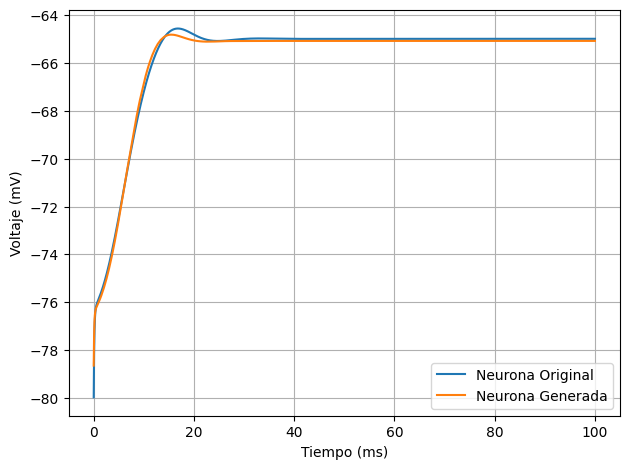

In [26]:
plot_basic("data/basic.txt", "Neurona Original")
plot_basic("data/replicated.txt", "Neurona Generada")

plt.xlabel("Tiempo (ms)")
plt.ylabel("Voltaje (mV)")
plt.title("")
plt.grid(True)
plt.legend()
plt.tight_layout()
#plt.show()
plt.savefig("img/neuron_replicated.png", format='png', dpi=200)


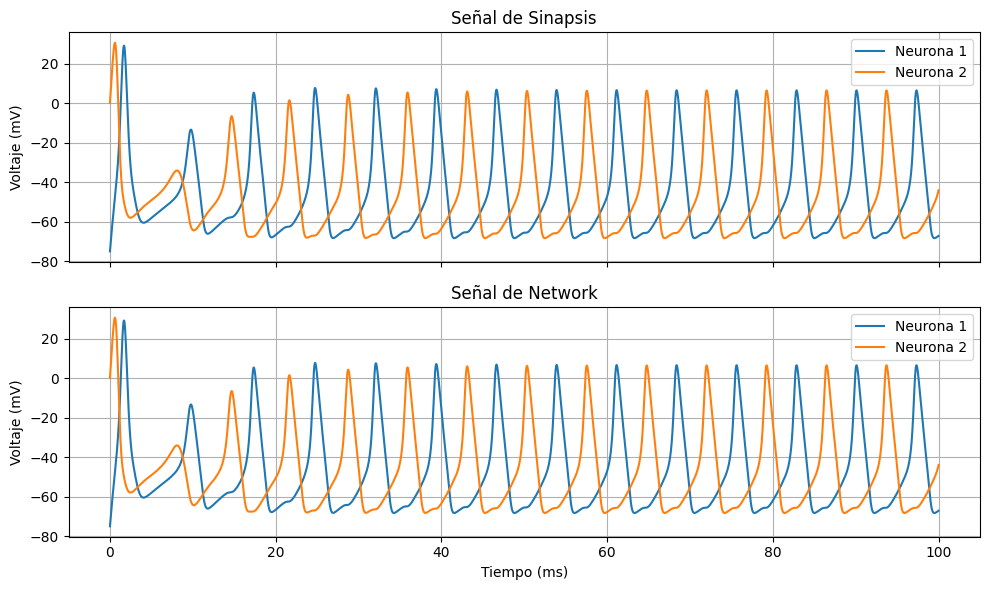

In [27]:
fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Plot from synapsis.txt
plt.sca(axs[0])  # Set current axis
plot_synapsis("data/synapsis.txt", "Neurona 1", "Neurona 2")
plt.title("Señal de Sinapsis")
plt.ylabel("Voltaje (mV)")
plt.grid(True)
plt.legend()

# Plot from network.txt
plt.sca(axs[1])  # Set current axis
plot_synapsis("data/network.txt", "Neurona 1", "Neurona 2")
plt.title("Señal de Network")
plt.xlabel("Tiempo (ms)")
plt.ylabel("Voltaje (mV)")
plt.grid(True)
plt.legend()

plt.tight_layout()
#plt.show()
plt.savefig("img/network_test.png", format='png', dpi=200)


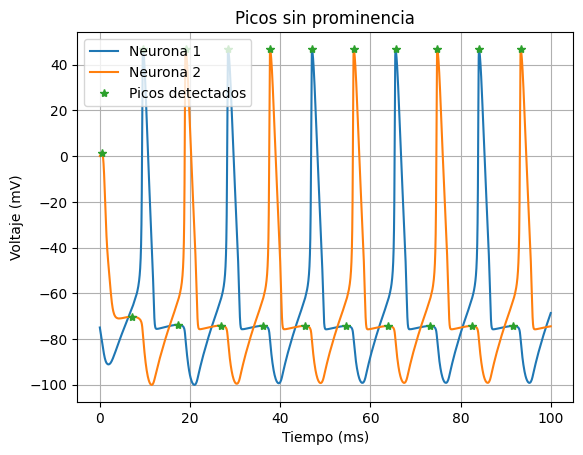

In [41]:
plot_synapsis("data/peaks_signal.txt", "Neurona 1", "Neurona 2")
plot_peaks("data/raw_peaks.txt", "Picos detectados")
plt.title("Picos sin prominencia")
plt.xlabel("Tiempo (ms)")
plt.ylabel("Voltaje (mV)")
plt.grid(True)
plt.legend()
plt.show()
#plt.savefig("img/peaks.png", format='png', dpi=200)

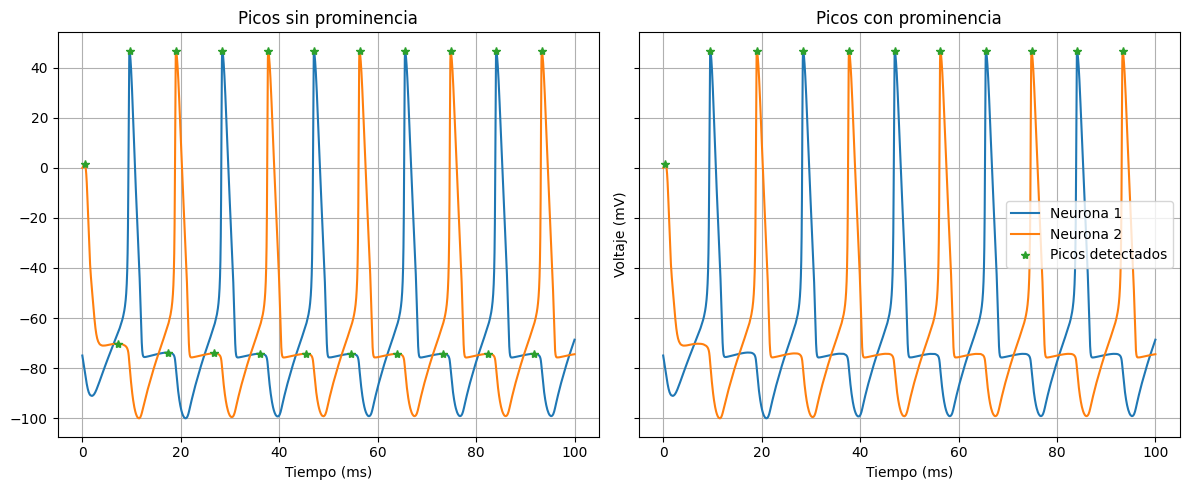

In [29]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Left subplot: synapsis.txt
plt.sca(axs[0])  # Set current axis
plot_synapsis("data/peaks_signal.txt", "Neurona 1", "Neurona 2")
plot_peaks("data/raw_peaks.txt", "Picos detectados")
plt.title("Picos sin prominencia")
plt.xlabel("Tiempo (ms)")
plt.grid(True)

# Right subplot: network.txt
plt.sca(axs[1])  # Set current axis
plot_synapsis("data/peaks_signal.txt", "Neurona 1", "Neurona 2")
plot_peaks("data/refined_peaks.txt", "Picos detectados")
plt.title("Picos con prominencia")
plt.xlabel("Tiempo (ms)")
plt.ylabel("Voltaje (mV)")
plt.grid(True)
plt.legend()

plt.tight_layout()
#plt.show()
plt.savefig("img/refined_peaks.png", format='png', dpi=200)

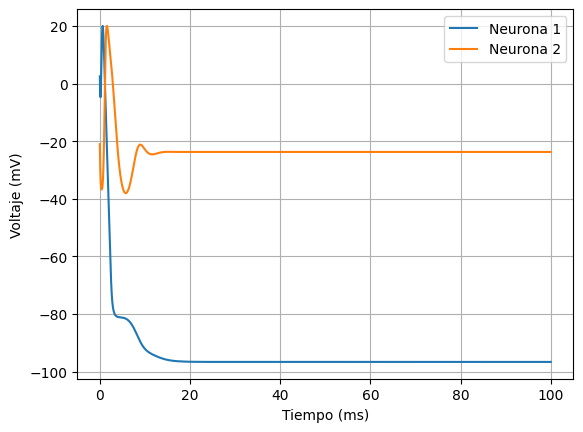

In [30]:
plot_synapsis("data/amplitude.txt", "Neurona 1", "Neurona 2")

plt.xlabel("Tiempo (ms)")
plt.ylabel("Voltaje (mV)")
plt.grid(True)
plt.legend()
#plt.show()
plt.savefig("img/amplitude.png", format='png', dpi=200)

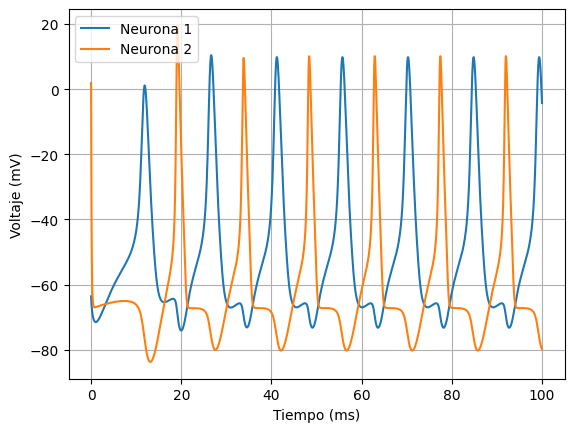

In [31]:
plot_synapsis("data/amplitude_count.txt", "Neurona 1", "Neurona 2")

plt.xlabel("Tiempo (ms)")
plt.ylabel("Voltaje (mV)")
plt.grid(True)
plt.legend()
#plt.show()
plt.savefig("img/amplitude_count.png", format='png', dpi=200)

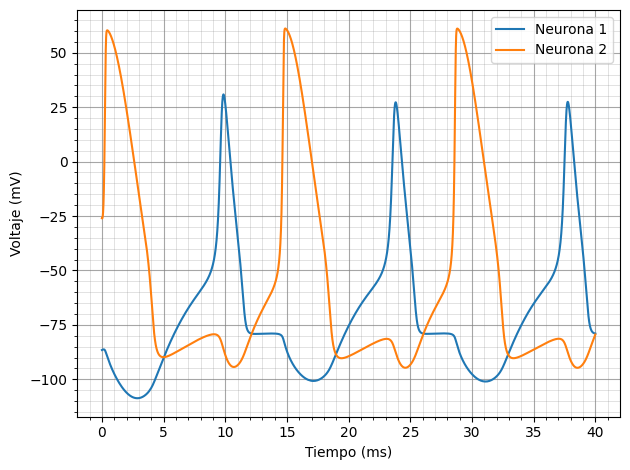

In [101]:
from matplotlib.ticker import AutoMinorLocator, MultipleLocator  # tools for tick spacing


x, y1, y2 = points_synapsis("data/spaced_peaks.txt")


limit = 40000
plt.plot(x[:limit], y1[:limit], label="Neurona 1")
plt.plot(x[:limit], y2[:limit], label="Neurona 2")

ax = plt.gca()
ax.set_xlabel("Tiempo (ms)")
ax.set_ylabel("Voltaje (mV)")


ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())


ax.grid(which="major", color="grey", linewidth=0.8, alpha=0.7)
ax.grid(which="minor", color="grey", linewidth=0.4, alpha=0.4)

plt.legend()
plt.tight_layout()
#plt.show()
plt.savefig("img/spaced_peaks.png", format='png', dpi=200)

In [33]:
import numpy as np

a = 1.5  # Puedes cambiar el valor de a para ajustar la anchura de la Gaussiana
x = np.linspace(-5, 5, 1000)

# Funciones
lorentz = 1 / (1 + x**2)
gauss = np.exp(-x**2 / (2 * a**2))

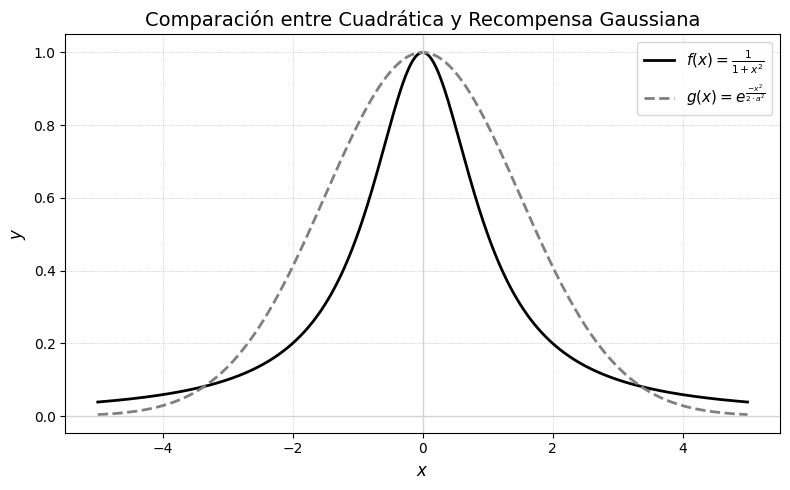

In [34]:
fig, ax = plt.subplots(figsize=(8, 5))

# Dibujar ambas curvas
ax.plot(x, lorentz, label=r'$f(x) = \frac{1}{1 + x^2}$', color='black', linewidth=2)
ax.plot(x, gauss, label=r'$g(x) = e^{{\frac{-x^2}{2 \cdot a^2}}}$', color='gray', linestyle='--', linewidth=2)

# Etiquetas y leyenda
ax.set_xlabel(r'$x$', fontsize=12)
ax.set_ylabel(r'$y$', fontsize=12)
ax.set_title('Comparación entre Cuadrática y Recompensa Gaussiana', fontsize=14)
ax.legend(fontsize=11, loc='upper right')

# Estética
ax.grid(True, linestyle=':', linewidth=0.5)
ax.axhline(0, color='lightgray', linewidth=1)
ax.axvline(0, color='lightgray', linewidth=1)

plt.tight_layout()
#plt.show()
plt.savefig("img/gauss_vs_cuad.png", format='png', dpi=200)

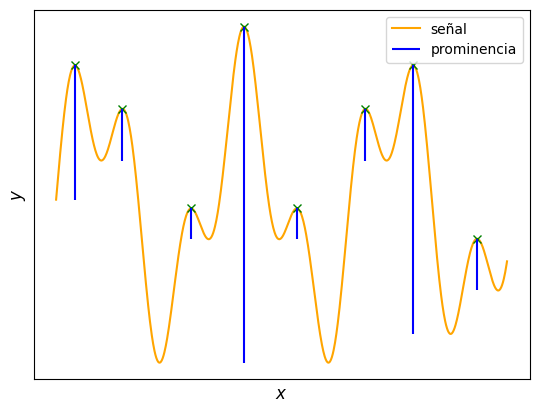

In [35]:
import numpy as np
from scipy.signal import find_peaks, peak_prominences
import matplotlib.pyplot as plt


x = np.linspace(0, 6 * np.pi, 1000)
x = np.sin(x) + 0.6 * np.sin(2.6 * x)

peaks, _ = find_peaks(x)
prominences = peak_prominences(x, peaks)[0]
np.array([1.24159486, 0.47840168, 0.28470524, 3.10716793, 0.284603  ,
       0.47822491, 2.48340261, 0.47822491])
contour_heights = x[peaks] - prominences


fig, ax = plt.subplots()

ax.plot(x, color="orange", label="señal")
ax.plot(peaks, x[peaks], "x", color="green")
ax.vlines(x=peaks, ymin=contour_heights, ymax=x[peaks], colors="blue", label="prominencia")

ax.set_xlabel(r'$x$', fontsize=12)
ax.set_ylabel(r'$y$', fontsize=12)

ax.set_xticks([])
ax.set_yticks([])
ax.legend()

#plt.show()
plt.savefig("img/prominence.png", format='png', dpi=200)

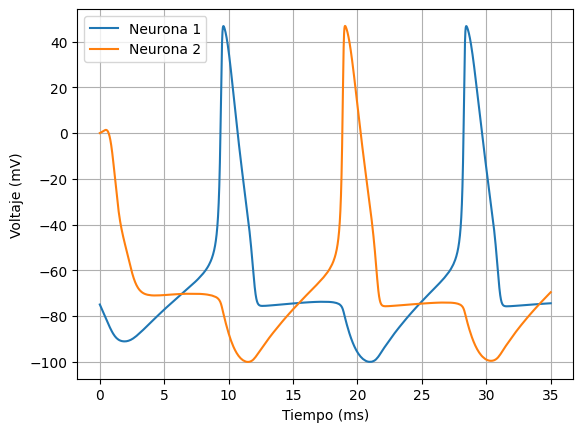

In [46]:
x, y1, y2= points_synapsis("data/peaks_signal.txt")

limit = 350000
plt.plot(x[:limit], y1[:limit], label="Neurona 1")
plt.plot(x[:limit], y2[:limit], label="Neurona 2")

plt.xlabel("Tiempo (ms)")
plt.ylabel("Voltaje (mV)")
plt.grid(True)
plt.legend()
plt.savefig("img/distancias.png", format='png', dpi=200)


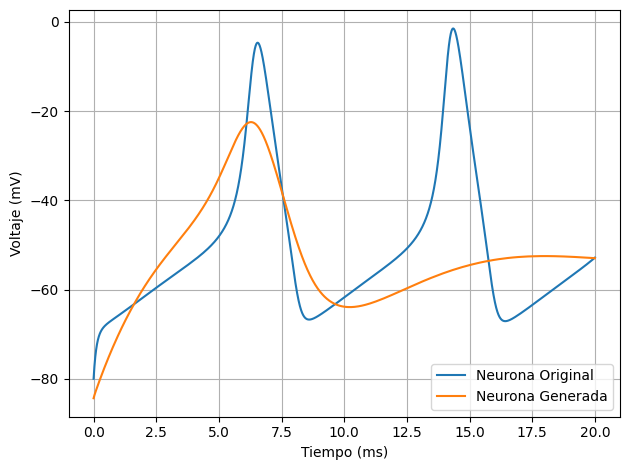

In [132]:
plot_basic("build/basic.txt", "Neurona Original")
plot_basic("build/recreated.txt", "Neurona Generada")

plt.xlabel("Tiempo (ms)")
plt.ylabel("Voltaje (mV)")
plt.title("")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("img/neuron_replicated_square.png", format='png', dpi=200)

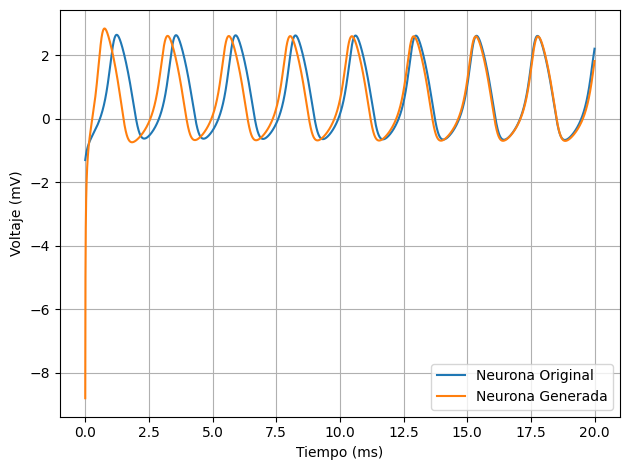

<Figure size 640x480 with 0 Axes>

In [ ]:
plot_basic("build/model.txt", "Neurona Original", 20000)
plot_basic("build/model_recreated.txt", "Neurona Generada", 20000)

plt.xlabel("Tiempo (ms)")
plt.ylabel("Voltaje (mV)")
plt.title("")
plt.grid(True)
plt.legend()
plt.tight_layout()
#plt.show()
plt.savefig("img/alternative_model.png", format='png', dpi=200)

In [124]:
import re
import numpy as np
import pandas as pd

def parse_ga_log(path: str):
    """Return four NumPy arrays: generation, best, average, worst."""
    gens, best, avg, worst, std = [], [], [], [], []

    pat_gen = re.compile(r"\[Generation\s+(\d+)\]")
    pat_val = re.compile(r":\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)")

    with open(path, encoding="utf-8") as f:
        for line in f:
            m_gen = pat_gen.search(line)
            if m_gen:                                 # header line
                gens.append(int(m_gen.group(1)))
                continue

            m_val = pat_val.search(line)
            if m_val:
                val = float(m_val.group(1))
                if   "Best Fitness"    in line: best.append(val)
                elif "Average Fitness" in line: avg.append(val)
                elif "Worst Fitness"   in line: worst.append(val)
                elif "Std Dev"         in line: std.append(val)

    # quick consistency check
    n = len(gens)
    if not (n == len(best) == len(avg) == len(worst)):
        raise ValueError("Log appears malformed (metric counts differ)")

    return (
        np.array(gens,  dtype=int),
        np.array(best,  dtype=float),
        np.array(avg,   dtype=float),
        np.array(worst, dtype=float),
        np.array(std, dtype=float),
    )


def plot_fitness(
    generation,
    best,
    average,
    worst,
    std_dev,
):
    plt.figure(figsize=(10, 6))

    # main curves
    plt.plot(generation, best,    label="Mejor individuo")
    plt.plot(generation, average, label="Individuo medio")
    plt.plot(generation, worst,   label="Peor individuo")

    # ±1 σ band around the average
    upper = average + std_dev
    lower = average - std_dev
    plt.fill_between(
        generation,
        lower,
        upper,
        alpha=0.15,
        label="± σ",
    )

    plt.xlabel("Generación")
    plt.ylabel("Puntuación de aptitud")
    plt.title("Pogreso del algoritmo genético")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()


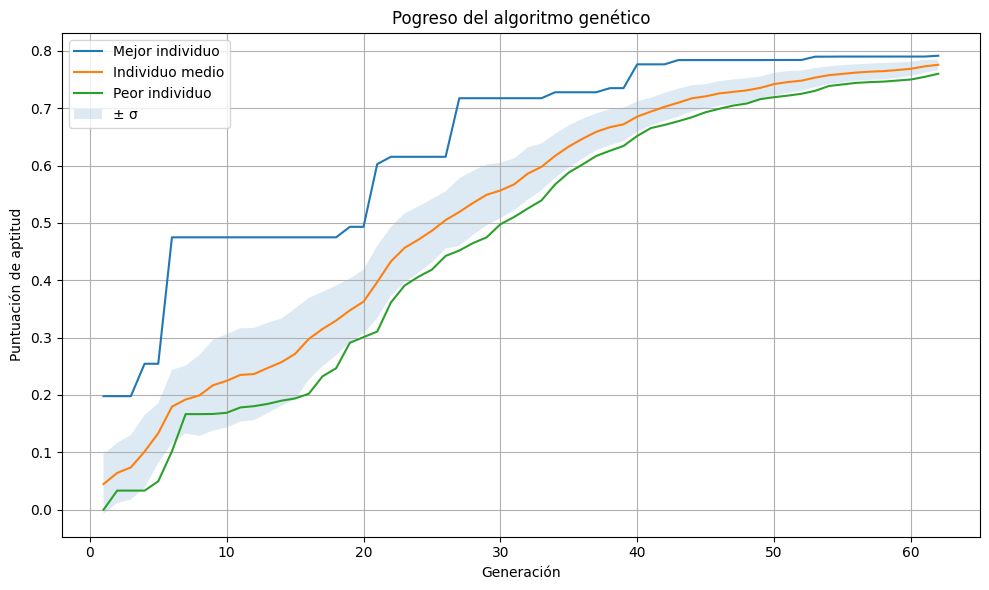

In [126]:
gens, best, avg, worst, std = parse_ga_log("data/fitness.txt")
plot_fitness(gens, best, avg, worst, std)
#plt.show()
plt.savefig("img/evolucion_GA.png", format='png', dpi=200)

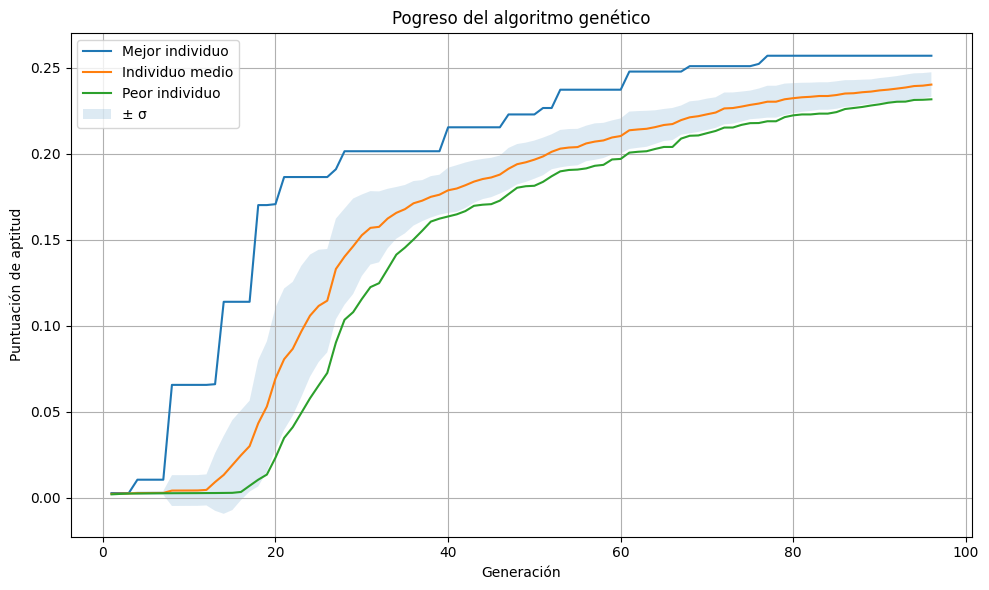

In [129]:
gens, best, avg, worst, std = parse_ga_log("data/cuadratic_fitness.txt")
plot_fitness(gens, best, avg, worst, std)
#plt.show()
plt.savefig("img/evolucion_GA_cuadriatic.png", format='png', dpi=200)